In [39]:
%load_ext autoreload
%autoreload 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
from collections import Counter
import math
import pandas as pd
import matplotlib.pyplot as plt
from methods import (CriterionNode, HierarchicalElectreTriB, set_equal_weights_topdown, class_acceptability_smaa, 
                     plot_country_pies_smaa, plot_acceptability_smaa, params_to_df, country_hierarchy, compute_lambdas)

In [41]:
raw = pd.read_csv("Freedom_and_Prosperity.csv", decimal=",")
print(f"Raw data: {raw.shape[0]} rows x {raw.shape[1]} columns")

# criteria
leaf_cols = [
    # Economic subindex
    "Proper_Rights", "Trade_Freedom", "Investm_Freedom", "Womens_Economic_Freedom",
    # Political subindex
    "PF_Elections", "Civil_Liberties", "Political_Rights", "Legislative_Constraints_on_the_Executive",
    # Legal subindex
    "Clarity_of_the_Law", "Judicial_Independence_and_Effectiveness", "Bureaucracy_and_Corruption",
    "Security", "Informality",
    # Prosperity
    "Income", "Environment", "Minorities", "Health", "Education", "Inequality",
]

# Keep only countries and only the year 2024
df = raw[(raw["Index_Year"] == 2024) & (raw["ISO3"].notna())].copy()
print(f"Countries in 2024: {df.shape[0]}")

# Drop countries with missing values in the elementary criteria
df = df.dropna(subset=leaf_cols)
print(f"Complete countries (no missing values): {df.shape[0]}")

# Keep only the criteria columns, indexed by country name
df = df.set_index("Name")[leaf_cols]
print(f"\n{df.shape[0]} countries x {df.shape[1]} criteria")

df.head()

Raw data: 5610 rows x 57 columns
Countries in 2024: 164
Complete countries (no missing values): 151

151 countries x 19 criteria


,Proper_Rights,Trade_Freedom,Investm_Freedom,Womens_Economic_Freedom,PF_Elections,Civil_Liberties,Political_Rights,Legislative_Constraints_on_the_Executive,Clarity_of_the_Law,Judicial_Independence_and_Effectiveness,Bureaucracy_and_Corruption,Security,Informality,Income,Environment,Minorities,Health,Education,Inequality
Name,,,,,,,,,,,,,,,,,,,
Angola,33.909381,33.410951,30.0,79.375,76.466667,64.30,55.35,17.2,45.983607,44.040167,29.926194,57.477784,56.946183,50.147485,60.720898,41.396151,63.271312,50.720767,36.342593
Albania,44.205751,93.027856,60.0,91.250,82.900000,93.25,75.90,68.2,57.076503,70.222170,45.890337,68.104440,73.091364,65.245762,70.600380,59.442325,90.660184,73.716172,63.657407
United Arab Emirates,76.338100,88.628857,50.0,82.500,29.866667,46.30,5.25,13.8,66.543716,39.614388,75.545517,78.110082,79.224030,87.491842,76.744827,51.453732,96.704562,87.557582,80.324074
Argentina,47.924284,43.020571,65.0,79.375,95.733333,87.60,81.15,81.6,53.524590,69.624609,39.167640,61.810356,71.214018,72.069277,74.537699,74.048145,86.626334,88.536107,63.657407
Armenia,54.473859,85.140215,70.0,90.625,89.233333,82.20,80.95,61.0,59.986339,48.077975,45.870747,47.601900,56.445557,66.366509,69.386882,62.291859,83.497222,77.623469,72.222222


In [42]:
Economic = CriterionNode("Economic_Subindex",
                         children=[
                             CriterionNode("Proper_Rights", leaf_id="Proper_Rights"),
                             CriterionNode("Trade_Freedom", leaf_id="Trade_Freedom"),
                             CriterionNode("Investm_Freedom", leaf_id="Investm_Freedom"),
                             CriterionNode("Womens_Economic_Freedom", leaf_id="Womens_Economic_Freedom"),
                         ])

Political = CriterionNode("Political_Subindex",
                          children=[
                              CriterionNode("PF_Elections", leaf_id="PF_Elections"),
                              CriterionNode("Civil_Liberties", leaf_id="Civil_Liberties"),
                              CriterionNode("Political_Rights", leaf_id="Political_Rights"),
                              CriterionNode("Legislative_Constraints_on_the_Executive",
                                            leaf_id="Legislative_Constraints_on_the_Executive"),
                          ])

Legal = CriterionNode("Legal_Subindex",
                      children=[
                          CriterionNode("Clarity_of_the_Law", leaf_id="Clarity_of_the_Law"),
                          CriterionNode("Judicial_Independence_and_Effectiveness",
                                        leaf_id="Judicial_Independence_and_Effectiveness"),
                          CriterionNode("Bureaucracy_and_Corruption", leaf_id="Bureaucracy_and_Corruption"),
                          CriterionNode("Security", leaf_id="Security"),
                          CriterionNode("Informality", leaf_id="Informality"),
                      ])

Freedom = CriterionNode("Freedom",
                        children=[Economic, Political, Legal])

Prosperity = CriterionNode("Prosperity",
                           children=[
                               CriterionNode("Income", leaf_id="Income"),
                               CriterionNode("Environment", leaf_id="Environment"),
                               CriterionNode("Minorities", leaf_id="Minorities"),
                               CriterionNode("Health", leaf_id="Health"),
                               CriterionNode("Education", leaf_id="Education"),
                               CriterionNode("Inequality", leaf_id="Inequality"),
                           ])

Root = CriterionNode("Freedom_and_Prosperity",
                     children=[Freedom, Prosperity])

In [43]:
leaves = Root.leaves()
print(f"{len(leaves)} elementary criteria (leaves):")
print(leaves)

19 elementary criteria (leaves):
['Proper_Rights', 'Trade_Freedom', 'Investm_Freedom', 'Womens_Economic_Freedom', 'PF_Elections', 'Civil_Liberties', 'Political_Rights', 'Legislative_Constraints_on_the_Executive', 'Clarity_of_the_Law', 'Judicial_Independence_and_Effectiveness', 'Bureaucracy_and_Corruption', 'Security', 'Informality', 'Income', 'Environment', 'Minorities', 'Health', 'Education', 'Inequality']


In [44]:
weights = set_equal_weights_topdown(Root, 1.0)

print("weights per leaf:")
for lf in leaves:
    print(f"  {lf:42s} w = {weights[lf]:.4f}")
print(f"\nsum Freedom    = {sum(weights[lf] for lf in Freedom.leaves()):.4f}")
print(f"sum Prosperity = {sum(weights[lf] for lf in Prosperity.leaves()):.4f}")
for sub in (Economic, Political, Legal):
    print(f"sum {sub.name:18s} = {sum(weights[lf] for lf in sub.leaves()):.4f}")

weights per leaf:
  Proper_Rights                              w = 0.0417
  Trade_Freedom                              w = 0.0417
  Investm_Freedom                            w = 0.0417
  Womens_Economic_Freedom                    w = 0.0417
  PF_Elections                               w = 0.0417
  Civil_Liberties                            w = 0.0417
  Political_Rights                           w = 0.0417
  Legislative_Constraints_on_the_Executive   w = 0.0417
  Clarity_of_the_Law                         w = 0.0333
  Judicial_Independence_and_Effectiveness    w = 0.0333
  Bureaucracy_and_Corruption                 w = 0.0333
  Security                                   w = 0.0333
  Informality                                w = 0.0333
  Income                                     w = 0.0833
  Environment                                w = 0.0833
  Minorities                                 w = 0.0833
  Health                                     w = 0.0833
  Education                   

In [45]:
q = {lf: 4.0 for lf in leaves}
p = {lf: 6.0 for lf in leaves}
v = {lf: 40.0 for lf in leaves}

lambda_frac = 0.75
lambdas = compute_lambdas(Root, weights, lambda_frac)

print("lambdas per node:")
for name, lam in lambdas.items():
    print(f"  {name:42s} lambda = {lam:.4f}")

categories = ["Class_1", "Class_2", "Class_3"]  # Class_3 is the best
b1 = {lf: 65.0 for lf in leaves}  # boundary profile between Class_1 and Class_2
b2 = {lf: 85.0 for lf in leaves}  # boundary profile between Class_2 and Class_3
profiles = {"b1": b1, "b2": b2}

lambdas per node:
  Freedom_and_Prosperity                     lambda = 0.7500
  Freedom                                    lambda = 0.3750
  Economic_Subindex                          lambda = 0.1250
  Political_Subindex                         lambda = 0.1250
  Legal_Subindex                             lambda = 0.1250
  Prosperity                                 lambda = 0.3750


In [46]:
model = HierarchicalElectreTriB(
    root=Root,
    weights=weights,
    q=q,
    p=p,
    v=v,
    lambdas=lambdas,
    profiles=profiles,
    categories=categories,
    relation="O3")

In [47]:
def classify(procedure):
    alternatives_dict = {}
    for alternative_name in df.index:
        alt = df.loc[alternative_name].to_dict()
        alternatives_dict[alternative_name] = model.assign_all_nodes(alt, procedure=procedure)
    return pd.DataFrame(alternatives_dict).T


res_pess = classify("pessimistic")

# order the columns
node_order = list(lambdas.keys())
res_pess = res_pess[node_order]
res_pess

,Freedom_and_Prosperity,Freedom,Economic_Subindex,Political_Subindex,Legal_Subindex,Prosperity
Angola,Class_1,Class_1,Class_1,Class_1,Class_1,Class_1
Albania,Class_2,Class_1,Class_1,Class_2,Class_1,Class_2
United Arab Emirates,Class_1,Class_1,Class_1,Class_1,Class_1,Class_2
Argentina,Class_2,Class_1,Class_1,Class_3,Class_1,Class_2
Armenia,Class_2,Class_1,Class_1,Class_2,Class_1,Class_2
...,...,...,...,...,...,...
Vietnam,Class_1,Class_1,Class_1,Class_1,Class_1,Class_2
Yemen,Class_1,Class_1,Class_1,Class_1,Class_1,Class_1
South Africa,Class_1,Class_1,Class_1,Class_3,Class_1,Class_1
Zambia,Class_1,Class_1,Class_1,Class_2,Class_1,Class_1


Distribution in the global class (Freedom_and_Prosperity):
Freedom_and_Prosperity
Class_1    96
Class_2    38
Class_3    17
Name: count, dtype: int64


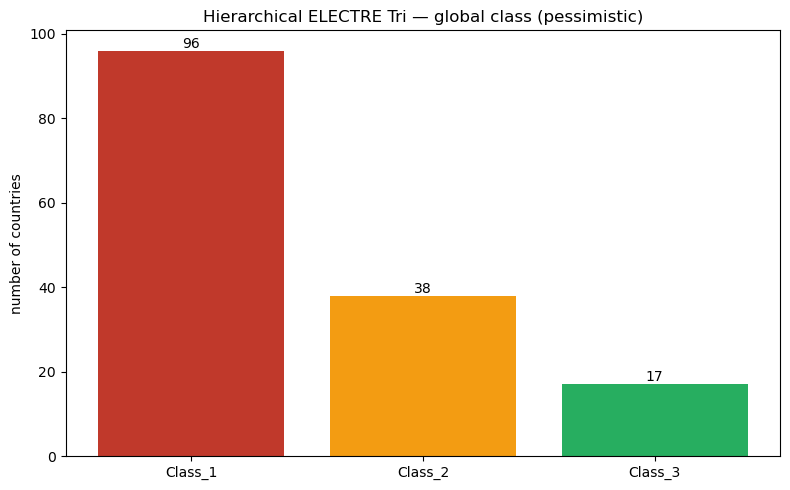

In [48]:
class_counts = res_pess["Freedom_and_Prosperity"].value_counts().reindex(categories, fill_value=0)
print("Distribution in the global class (Freedom_and_Prosperity):")
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(class_counts.index, class_counts.values, color=["#c0392b", "#f39c12", "#27ae60"])
ax.set_ylabel("number of countries")
ax.set_title("Hierarchical ELECTRE Tri — global class (pessimistic)")
for x, y in zip(class_counts.index, class_counts.values):
    ax.text(x, y, str(y), ha="center", va="bottom")
plt.tight_layout()
plt.show()


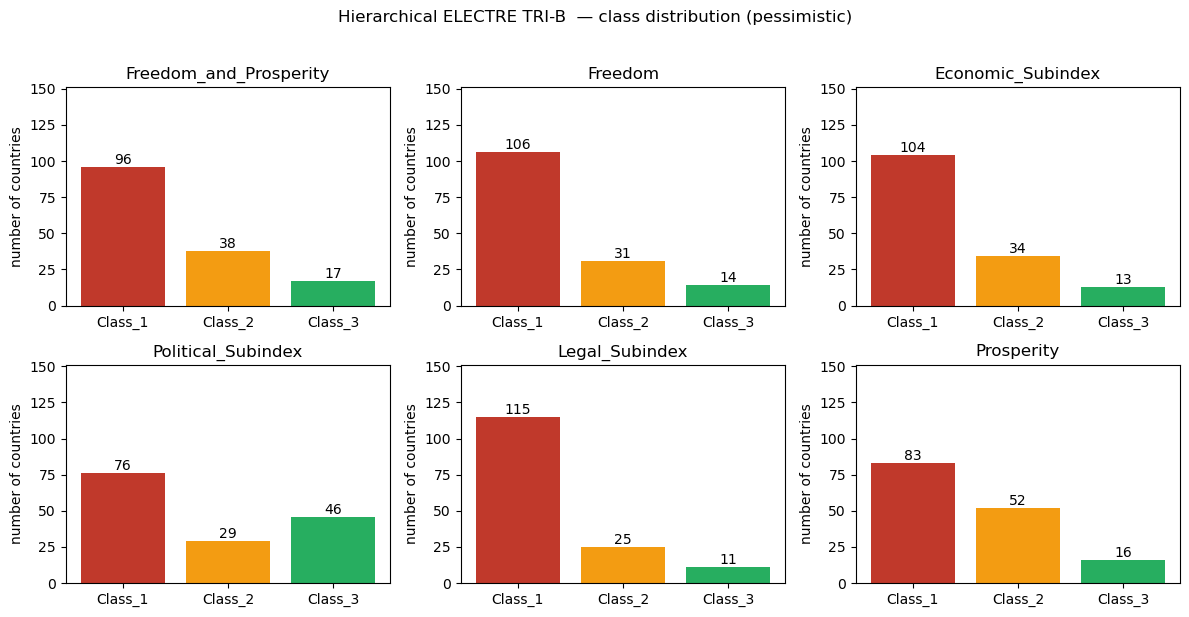

In [49]:
nodes = list(lambdas.keys())  # root + dimensions + subdimensions
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#27ae60"}

ncols = 3
nrows = math.ceil(len(nodes) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, node in zip(axes, nodes):
    class_counts = res_pess[node].value_counts().reindex(categories, fill_value=0)
    ax.bar(class_counts.index, class_counts.values, color=[colors[c] for c in class_counts.index])
    ax.set_title(node)
    ax.set_ylabel("number of countries")
    ax.set_ylim(0, len(df))
    for x, y in zip(class_counts.index, class_counts.values):
        ax.text(x, y, str(y), ha="center", va="bottom")

# turn off the leftover subplots
for ax in axes[len(nodes):]:
    ax.axis("off")

fig.suptitle("Hierarchical ELECTRE TRI-B  — class distribution (pessimistic)",
             y=1.02)
plt.tight_layout()
plt.show()

In [50]:
_ = country_hierarchy("Brazil", Root, df, res_pess)

Country: Brazil
Freedom_and_Prosperity                                  -> Class_2
  Freedom                                               -> Class_1
    Economic_Subindex                                   -> Class_1
      Proper_Rights                                        (value = 61.94)
      Trade_Freedom                                        (value = 79.28)
      Investm_Freedom                                      (value = 40.00)
      Womens_Economic_Freedom                              (value = 85.00)
    Political_Subindex                                  -> Class_3
      PF_Elections                                         (value = 94.83)
      Civil_Liberties                                      (value = 80.95)
      Political_Rights                                     (value = 91.00)
      Legislative_Constraints_on_the_Executive             (value = 93.60)
    Legal_Subindex                                      -> Class_1
      Clarity_of_the_Law                         

# SMAA-TRI

## Fixed weights

In [51]:
N_SIM = 10000         
SEED = 42            

categories = ["Class_1", "Class_2", "Class_3"]  # Class_3 is the best

rng = np.random.default_rng(SEED)
nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}

counts = {c: {n: Counter() for n in nodes} for c in df.index}
params_fixed_w = []

for _ in range(N_SIM):
    q_s  = {lf: rng.uniform(3, 5)  for lf in leaves}
    p_s  = {lf: rng.uniform(5, 7)  for lf in leaves}
    v_s  = {lf: rng.uniform(30, 50) for lf in leaves}
    b1_s = {lf: rng.uniform(60, 70) for lf in leaves}
    b2_s = {lf: rng.uniform(80, 90) for lf in leaves}
    model.q, model.p, model.v = q_s, p_s, v_s
    model.profiles = {"b1": b1_s, "b2": b2_s}
    params_fixed_w.append({"q": q_s, "p": p_s, "v": v_s, "b1": b1_s, "b2": b2_s})

    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts[name][n][assigned[n]] += 1

params_fixed_w_df = params_to_df(params_fixed_w)
print(f"Simulation finished: {N_SIM} iterations.")
print(f"Parameters stored in 'params_fixed_w' (list of dicts) and "
      f"'params_fixed_w_df' {params_fixed_w_df.shape}.")

params_fixed_w_df

Simulation finished: 10000 iterations.
Parameters stored in 'params_fixed_w' (list of dicts) and 'params_fixed_w_df' (10000, 95).


param                 q                                                        \
id        Proper_Rights Trade_Freedom Investm_Freedom Womens_Economic_Freedom   
iteration                                                                       
0              4.547912      3.877757        4.717196                4.394736   
1              4.260565      3.723625        3.175300                3.236012   
2              4.873626      3.481941        3.245516                4.662225   
3              3.832525      3.098508        3.747228                4.047506   
4              4.105986      4.872280        4.560603                3.958739   
...                 ...           ...             ...                     ...   
9995           3.184695      4.818312        3.886937                4.819890   
9996           3.071831      4.700127        4.601285                4.653082   
9997           4.398291      4.008403        4.794176                4.020902   
9998           4.116433      4.930438        3.545721                3.523196   
9999           3.129184      4.842240        3.472292                3.180505   

param                                                    \
id        PF_Elections Civil_Liberties Political_Rights   
iteration                                                 
0             3.188355        4.951245         4.522279   
1             4.923795        4.817161         4.399414   
2             3.306569        3.358537         4.198766   
3             3.203344        4.666917         3.103924   
4             3.752719        4.973263         4.435520   
...                ...             ...              ...   
9995          4.944629        3.772884         4.447813   
9996          3.093183        4.668891         4.193349   
9997          4.132642        3.340268         4.337374   
9998          4.426406        4.768243         4.826242   
9999          3.877854        3.972194         3.012951   

param                                                                  \
id        Legislative_Constraints_on_the_Executive Clarity_of_the_Law   
iteration                                                               
0                                         4.572129           3.256227   
1                                         3.531740           4.938353   
2                                         4.749124           3.392869   
3                                         4.849684           3.198226   
4                                         4.902389           3.236957   
...                                            ...                ...   
9995                                      4.174914           4.689917   
9996                                      4.660357           3.945813   
9997                                      3.983398           4.899057   
9998                                      4.184344           4.450181   
9999                                      3.281612           4.144218   

param                                              ...  \
id        Judicial_Independence_and_Effectiveness  ...   
iteration                                          ...   
0                                        3.900772  ...   
1                                        4.557502  ...   
2                                        3.620647  ...   
3                                        4.687150  ...   
4                                        4.701067  ...   
...                                           ...  ...   
9995                                     4.598033  ...   
9996                                     4.073766  ...   
9997                                     3.811564  ...   
9998                                     3.372595  ...   
9999                                     3.360423  ...   

param                                          b2                             \
id        Judicial_Independence_and_Effectiveness Bureaucracy_and_Corruption   
iteration                                 

In [52]:
accept = {}
for name in df.index:
    row = {}
    for n in nodes:
        total = sum(counts[name][n].values())  
        for c in categories:
            row[(n, c)] = counts[name][n][c] / total
    accept[name] = row

acceptability = pd.DataFrame(accept).T
acceptability.columns = pd.MultiIndex.from_tuples(acceptability.columns, names=["node", "class"])
acceptability = acceptability[[(n, c) for n in nodes for c in categories]]

acceptability

node                 Freedom_and_Prosperity                 Freedom          \
class                               Class_1 Class_2 Class_3 Class_1 Class_2   
Angola                               1.0000  0.0000     0.0  1.0000  0.0000   
Albania                              0.0782  0.9218     0.0  0.8334  0.1666   
United Arab Emirates                 1.0000  0.0000     0.0  1.0000  0.0000   
Argentina                            0.0882  0.9118     0.0  1.0000  0.0000   
Armenia                              0.2481  0.7519     0.0  1.0000  0.0000   
...                                     ...     ...     ...     ...     ...   
Vietnam                              1.0000  0.0000     0.0  1.0000  0.0000   
Yemen                                1.0000  0.0000     0.0  1.0000  0.0000   
South Africa                         1.0000  0.0000     0.0  1.0000  0.0000   
Zambia                               1.0000  0.0000     0.0  1.0000  0.0000   
Zimbabwe                             1.0000  0.0000     0.0  1.0000  0.0000   

node                         Economic_Subindex                  \
class                Class_3           Class_1 Class_2 Class_3   
Angola                   0.0            1.0000  0.0000     0.0   
Albania                  0.0            1.0000  0.0000     0.0   
United Arab Emirates     0.0            0.9495  0.0505     0.0   
Argentina                0.0            1.0000  0.0000     0.0   
Armenia                  0.0            0.5245  0.4755     0.0   
...                      ...               ...     ...     ...   
Vietnam                  0.0            0.9837  0.0163     0.0   
Yemen                    0.0            1.0000  0.0000     0.0   
South Africa             0.0            1.0000  0.0000     0.0   
Zambia                   0.0            1.0000  0.0000     0.0   
Zimbabwe                 0.0            1.0000  0.0000     0.0   

node                 Political_Subindex                 Legal_Subindex  \
class                           Class_1 Class_2 Class_3        Class_1   
Angola                           1.0000  0.0000  0.0000         1.0000   
Albania                          0.0000  1.0000  0.0000         0.9994   
United Arab Emirates             1.0000  0.0000  0.0000         1.0000   
Argentina                        0.0000  0.1985  0.8015         1.0000   
Armenia                          0.0027  0.9973  0.0000         1.0000   
...                                 ...     ...     ...            ...   
Vietnam                          1.0000  0.0000  0.0000         1.0000   
Yemen                            1.0000  0.0000  0.0000         1.0000   
South Africa                     0.0000  0.0006  0.9994         1.0000   
Zambia                           0.0000  0.9050  0.0950         1.0000   
Zimbabwe                         1.0000  0.0000  0.0000         1.0000   

node                                 Prosperity                  
class                Class_2 Class_3    Class_1 Class_2 Class_3  
Angola                0.0000     0.0     1.0000  0.0000     0.0  
Albania               0.0006     0.0     0.0766  0.9234     0.0  
United Arab Emirates  0.0000     0.0     0.0073  0.9927     0.0  
Argentina             0.0000     0.0     0.0000  1.0000     0.0  
Armenia               0.0000     0.0     0.0000  1.0000     0.0  
...                      ...     ...        ...     ...     ...  
Vietnam               0.0000     0.0     0.4527  0.5473     0.0  
Yemen                 0.0000     0.0     1.0000  0.0000     0.0  
South Africa          0.0000     0.0     1.0000  0.0000     0.0  
Zambia                0.0000     0.0     1.0000  0.0000     0.0  
Zimbabwe              0.0000     0.0     1.0000  0.0000     0.0  

[151 rows x 18 columns]

In [53]:
class_acceptability_smaa(acceptability, categories, "Freedom_and_Prosperity").round(3)

class,Class_1,Class_2,Class_3
Switzerland,0.0,0.0,1.0
Denmark,0.0,0.0,1.0
Ireland,0.0,0.0,1.0
Iceland,0.0,0.0,1.0
Netherlands,0.0,0.0,1.0
...,...,...,...
Vietnam,1.0,0.0,0.0
Yemen,1.0,0.0,0.0
South Africa,1.0,0.0,0.0
Zambia,1.0,0.0,0.0


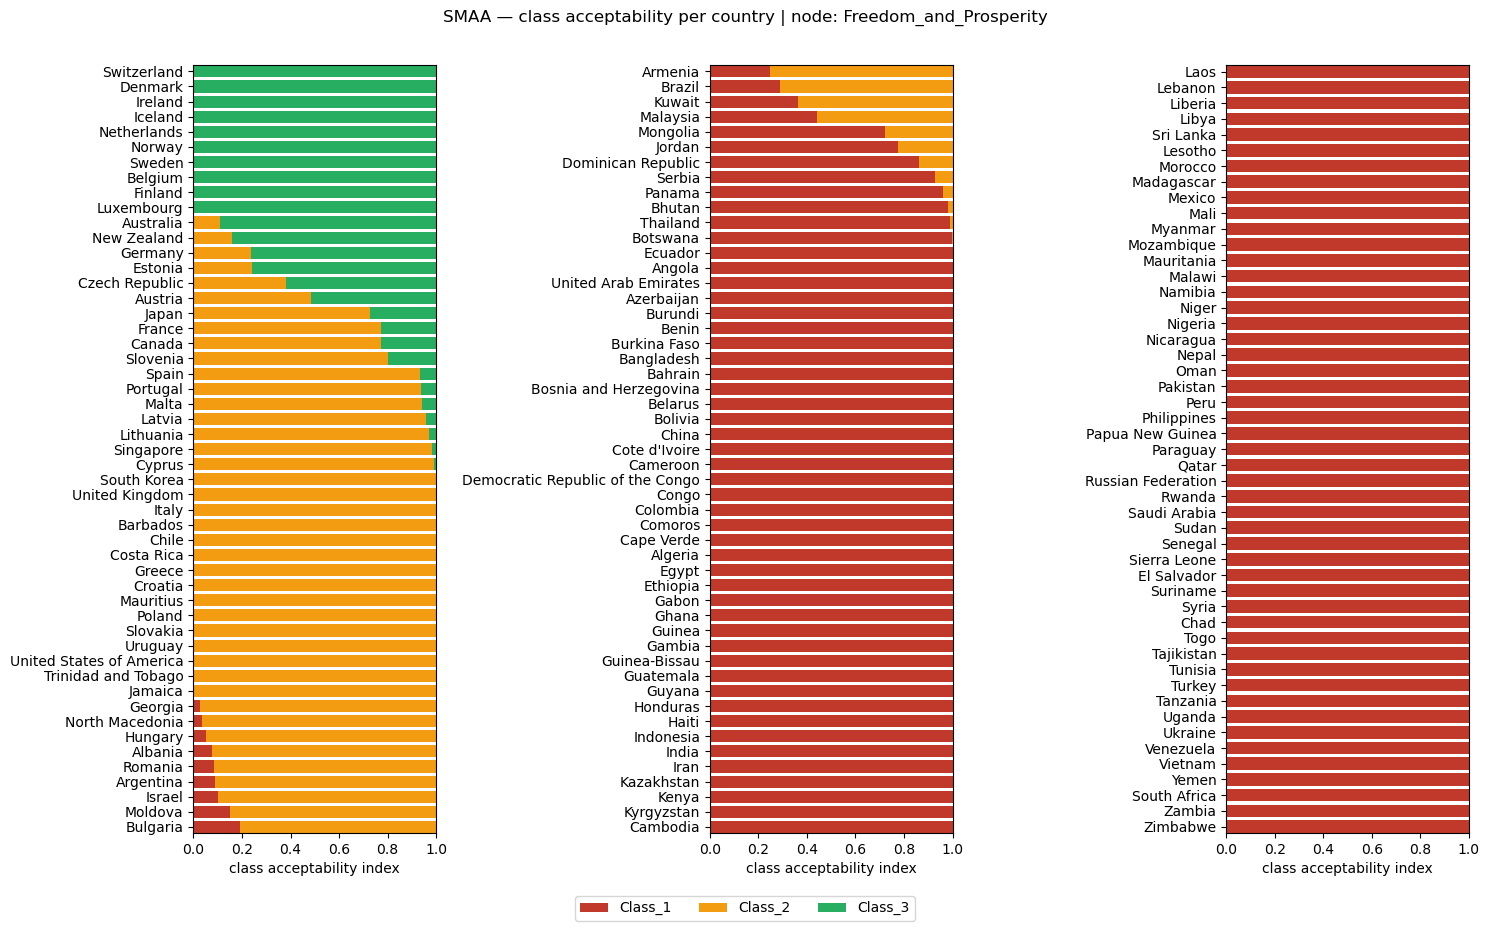

In [62]:
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#27ae60"}

plot_acceptability_smaa(acceptability, categories, colors, "Freedom_and_Prosperity")

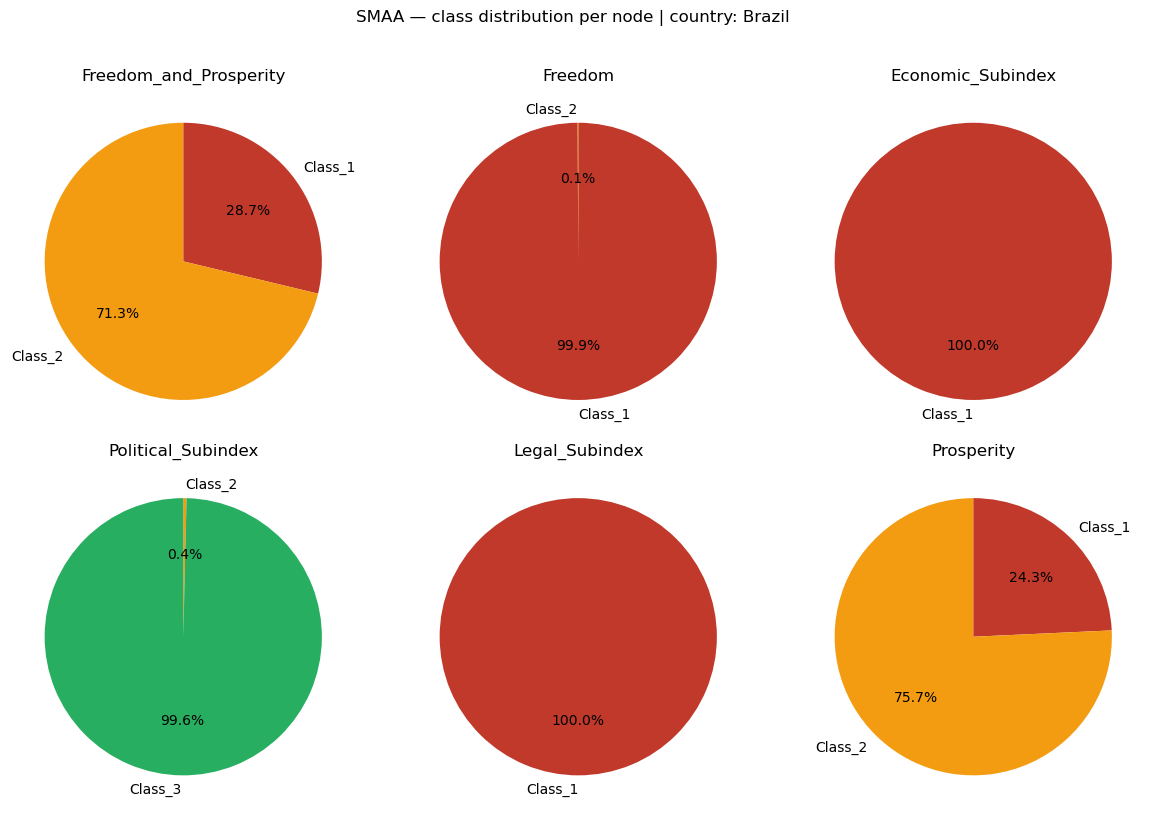

In [55]:
plot_country_pies_smaa(acceptability, nodes, categories, colors, "Brazil")

# SMAA-TRI

## Varying weights

In [56]:
# Varying-weights version
N_SIM = 10000          
SEED = 42             
rng = np.random.default_rng(SEED)
nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}
def sample_weights(node, weight, rng, out=None):
    """Split `weight` among the children with Dirichlet(1,...,1) (uniform on the
    simplex) and recurse down to the leaves. Preserves the hierarchy: on average
    it keeps each dimension's expected weight (Freedom≈0.5, etc.)."""
    if out is None:
        out = {}
    if node.is_leaf():
        out[node.leaf_id] = weight
        return out
    fracs = rng.dirichlet(np.ones(len(node.children)))
    for child, f in zip(node.children, fracs):
        sample_weights(child, weight * f, rng, out)
    return out

# counts_w[country][node] -> Counter({class: number of times})
counts_w = {c: {n: Counter() for n in nodes} for c in df.index}
params_varying_w = []

for _ in range(N_SIM):
    w   = sample_weights(Root, 1.0, rng)
    lam = compute_lambdas(Root, w, lambda_frac)
    q_s  = {lf: rng.uniform(3, 5)  for lf in leaves}
    p_s  = {lf: rng.uniform(5, 7)  for lf in leaves}
    v_s  = {lf: rng.uniform(30, 50) for lf in leaves}
    b1_s = {lf: rng.uniform(60, 70) for lf in leaves}
    b2_s = {lf: rng.uniform(80, 90) for lf in leaves}

    model.weights, model.lambdas = w, lam
    model.q, model.p, model.v = q_s, p_s, v_s
    model.profiles = {"b1": b1_s, "b2": b2_s}

    params_varying_w.append(
        {"weights": w, "lambdas": lam,
         "q": q_s, "p": p_s, "v": v_s, "b1": b1_s, "b2": b2_s}
    )

    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts_w[name][n][assigned[n]] += 1

# restore the base-scenario parameters in the model
model.weights, model.lambdas = weights, lambdas
model.q, model.p, model.v, model.profiles = q, p, v, profiles

params_varying_w_df = params_to_df(params_varying_w)
print(f"Simulation finished: {N_SIM} iterations.")
params_varying_w_df

Simulation finished: 10000 iterations.


param           weights                                                        \
id        Proper_Rights Trade_Freedom Investm_Freedom Womens_Economic_Freedom   
iteration                                                                       
0              0.105283      0.102189        0.226437                0.005747   
1              0.001831      0.023741        0.025209                0.007635   
2              0.098365      0.124264        0.041385                0.105765   
3              0.084299      0.045570        0.305626                0.035478   
4              0.030891      0.053992        0.044655                0.002995   
...                 ...           ...             ...                     ...   
9995           0.017754      0.010240        0.022915                0.020224   
9996           0.155250      0.000419        0.015620                0.062991   
9997           0.030922      0.011586        0.013249                0.071493   
9998           0.060826      0.023682        0.084710                0.041541   
9999           0.005581      0.005393        0.051632                0.010554   

param                                                    \
id        PF_Elections Civil_Liberties Political_Rights   
iteration                                                 
0             0.013711        0.000923         0.014267   
1             0.000144        0.008562         0.002534   
2             0.041455        0.020573         0.009981   
3             0.055335        0.098709         0.005814   
4             0.017167        0.016563         0.004910   
...                ...             ...              ...   
9995          0.006874        0.025399         0.003235   
9996          0.055901        0.014251         0.033825   
9997          0.114936        0.115747         0.041822   
9998          0.001717        0.001209         0.006920   
9999          0.013955        0.055018         0.128393   

param                                                                  \
id        Legislative_Constraints_on_the_Executive Clarity_of_the_Law   
iteration                                                               
0                                         0.022682           0.002829   
1                                         0.004668           0.001970   
2                                         0.056483           0.038834   
3                                         0.041231           0.020005   
4                                         0.029222           0.001135   
...                                            ...                ...   
9995                                      0.010892           0.004612   
9996                                      0.005451           0.025770   
9997                                      0.137110           0.053915   
9998                                      0.003384           0.052532   
9999                                      0.098908           0.003753   

param                                              ...  \
id        Judicial_Independence_and_Effectiveness  ...   
iteration                                          ...   
0                                        0.009007  ...   
1                                        0.009360  ...   
2                                        0.048430  ...   
3                                        0.003957  ...   
4                                        0.028792  ...   
...                                           ...  ...   
9995                                     0.021671  ...   
9996                                     0.135852  ...   
9997                                     0.141884  ...   
9998                                     0.001572  ...   
9999                                     0.028176  ...   

param                                          b2                             \
id        Judicial_Independence_and_Effectiveness Bureaucracy_and_Corruption   
iteration                                 

In [57]:
accept_w = {}
for name in df.index:
    row = {}
    for n in nodes:
        total = sum(counts_w[name][n].values())  
        for c in categories:
            row[(n, c)] = counts_w[name][n][c] / total
    accept_w[name] = row

acceptability_w = pd.DataFrame(accept_w).T
acceptability_w.columns = pd.MultiIndex.from_tuples(acceptability_w.columns, names=["node", "class"])
acceptability_w = acceptability_w[[(n, c) for n in nodes for c in categories]]

acceptability_w

node                 Freedom_and_Prosperity                 Freedom          \
class                               Class_1 Class_2 Class_3 Class_1 Class_2   
Angola                               1.0000  0.0000     0.0  1.0000  0.0000   
Albania                              0.2633  0.7367     0.0  0.7115  0.2885   
United Arab Emirates                 1.0000  0.0000     0.0  1.0000  0.0000   
Argentina                            0.2782  0.7218     0.0  0.8862  0.1138   
Armenia                              0.3757  0.6243     0.0  0.8664  0.1336   
...                                     ...     ...     ...     ...     ...   
Vietnam                              1.0000  0.0000     0.0  1.0000  0.0000   
Yemen                                1.0000  0.0000     0.0  1.0000  0.0000   
South Africa                         1.0000  0.0000     0.0  0.8720  0.1279   
Zambia                               0.9947  0.0053     0.0  0.9457  0.0543   
Zimbabwe                             1.0000  0.0000     0.0  1.0000  0.0000   

node                         Economic_Subindex                  \
class                Class_3           Class_1 Class_2 Class_3   
Angola                0.0000            1.0000  0.0000  0.0000   
Albania               0.0000            0.9489  0.0511  0.0000   
United Arab Emirates  0.0000            0.7239  0.2759  0.0002   
Argentina             0.0000            0.9900  0.0100  0.0000   
Armenia               0.0000            0.5343  0.4651  0.0006   
...                      ...               ...     ...     ...   
Vietnam               0.0000            0.8414  0.1585  0.0001   
Yemen                 0.0000            1.0000  0.0000  0.0000   
South Africa          0.0001            0.9940  0.0060  0.0000   
Zambia                0.0000            0.9880  0.0120  0.0000   
Zimbabwe              0.0000            1.0000  0.0000  0.0000   

node                 Political_Subindex                 Legal_Subindex  \
class                           Class_1 Class_2 Class_3        Class_1   
Angola                           1.0000  0.0000  0.0000         1.0000   
Albania                          0.0000  0.9628  0.0372         0.9349   
United Arab Emirates             1.0000  0.0000  0.0000         0.9542   
Argentina                        0.0000  0.3014  0.6986         0.9937   
Armenia                          0.1605  0.8154  0.0241         0.9998   
...                                 ...     ...     ...            ...   
Vietnam                          1.0000  0.0000  0.0000         0.9999   
Yemen                            1.0000  0.0000  0.0000         1.0000   
South Africa                     0.0000  0.0433  0.9567         0.9839   
Zambia                           0.0000  0.8221  0.1779         0.9990   
Zimbabwe                         0.9998  0.0002  0.0000         1.0000   

node                                 Prosperity                  
class                Class_2 Class_3    Class_1 Class_2 Class_3  
Angola                0.0000     0.0     0.9993  0.0007  0.0000  
Albania               0.0651     0.0     0.1725  0.8275  0.0000  
United Arab Emirates  0.0458     0.0     0.3248  0.6380  0.0372  
Argentina             0.0063     0.0     0.0222  0.9706  0.0072  
Armenia               0.0002     0.0     0.0529  0.9456  0.0015  
...                      ...     ...        ...     ...     ...  
Vietnam               0.0001     0.0     0.4370  0.5630  0.0000  
Yemen                 0.0000     0.0     1.0000  0.0000  0.0000  
South Africa          0.0161     0.0     1.0000  0.0000  0.0000  
Zambia                0.0010     0.0     1.0000  0.0000  0.0000  
Zimbabwe              0.0000     0.0     0.9999  0.0001  0.0000  

[151 rows x 18 columns]

In [58]:
class_acceptability_smaa(acceptability_w, categories, "Freedom_and_Prosperity").round(3)

class,Class_1,Class_2,Class_3
Ireland,0.0,0.033,0.967
Sweden,0.0,0.038,0.962
Denmark,0.0,0.046,0.954
Finland,0.0,0.054,0.946
Luxembourg,0.0,0.082,0.918
...,...,...,...
Venezuela,1.0,0.000,0.000
Vietnam,1.0,0.000,0.000
Yemen,1.0,0.000,0.000
South Africa,1.0,0.000,0.000


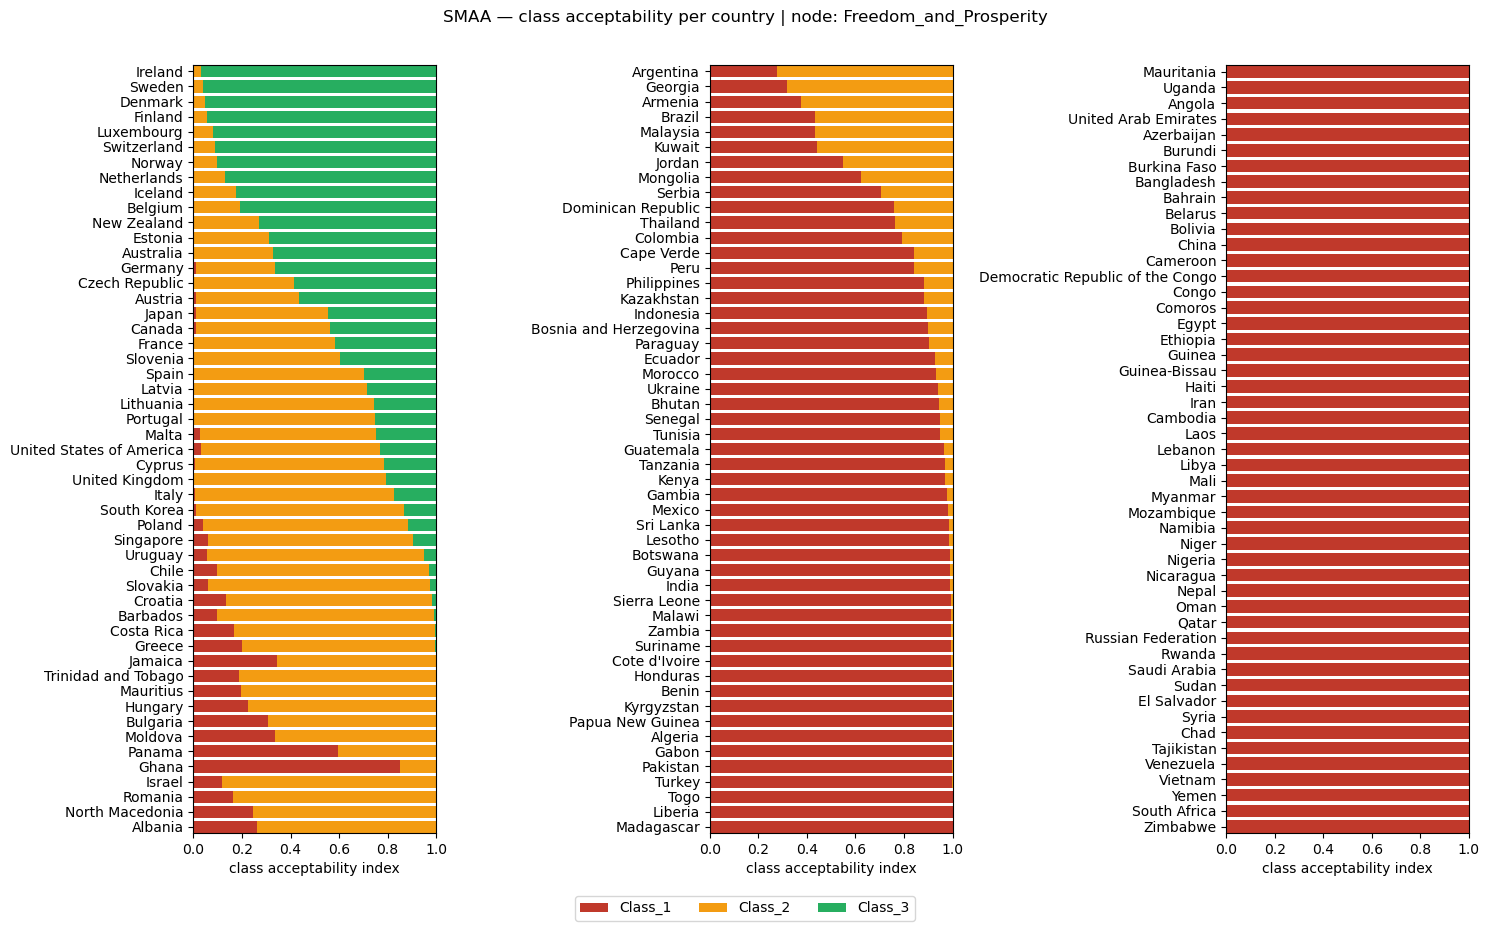

In [59]:
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#27ae60"}

plot_acceptability_smaa(acceptability_w, categories, colors, "Freedom_and_Prosperity")

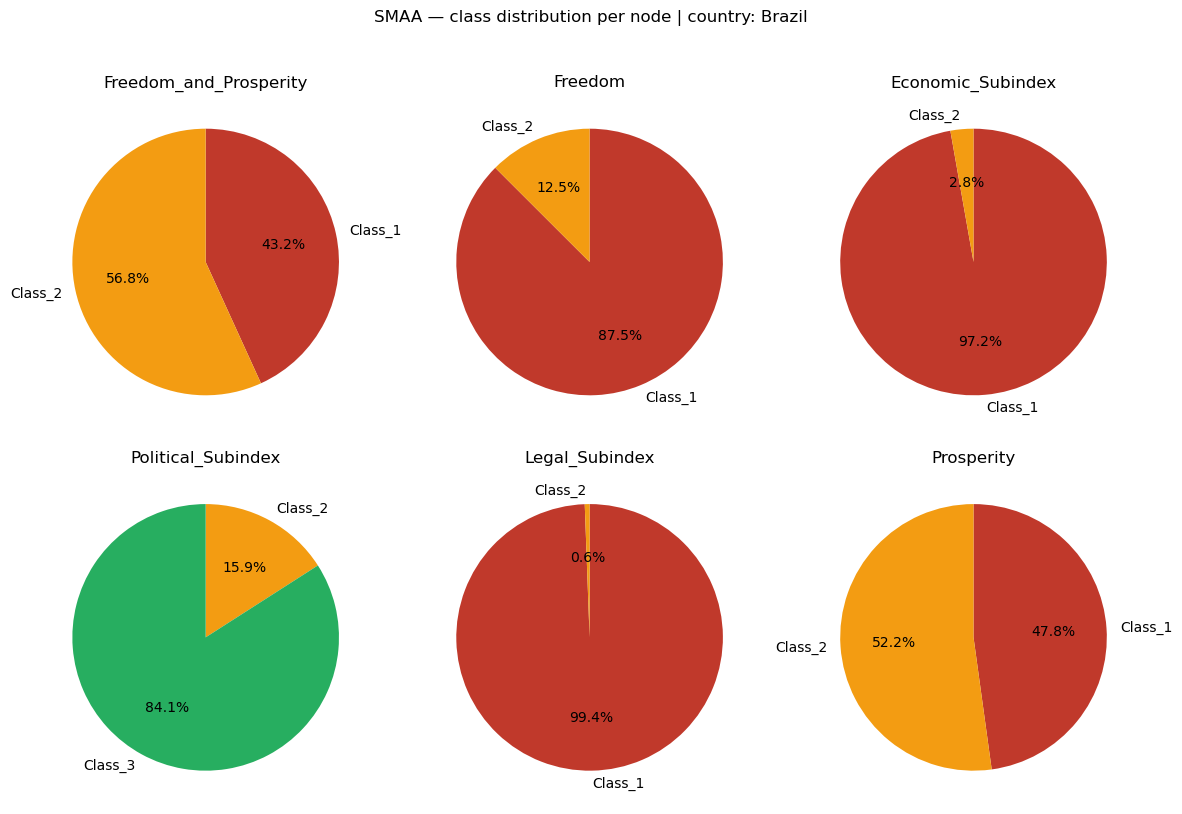

In [60]:
plot_country_pies_smaa(acceptability_w, nodes, categories, colors, "Brazil")